# Experiment 2: Loan Approval Prediction using Logistic Regression

**Course:** MTech AI - DTU
**Task Type:** Classification
**Model:** Logistic Regression

**Problem Statement:** Predict whether a customer's loan application should be approved based on income, credit
history, loan amount, and employment information.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

sns.set_style("whitegrid")
np.random.seed(42)


## 1. Dataset

No dataset file was provided with the assignment, so a synthetic dataset of 1000 loan applications is generated
here. `approved` is drawn probabilistically from a logistic function of the features (not a hard threshold), so
the labels carry realistic noise rather than being perfectly separable.


In [2]:
n = 1000

credit_history = np.random.choice([0, 1], n, p=[0.3, 0.7])          # 0 = bad, 1 = good
income = np.random.normal(50, 20, n).clip(10, 150).round(1)          # in thousands / month
loan_amount = np.random.normal(200, 80, n).clip(20, 500).round(1)    # in thousands
employment_type = np.random.choice(
    ["Salaried", "Self-Employed", "Unemployed"], n, p=[0.55, 0.35, 0.10]
)

emp_effect = {"Salaried": 0.5, "Self-Employed": 0.0, "Unemployed": -2.5}
emp = np.array([emp_effect[e] for e in employment_type])

logit = -2.5 + 3.5 * credit_history + 0.03 * income - 0.01 * loan_amount + emp
prob_approved = 1 / (1 + np.exp(-logit))
approved = np.random.binomial(1, prob_approved)

df = pd.DataFrame({
    "credit_history": credit_history,
    "income": income,
    "loan_amount": loan_amount,
    "employment_type": employment_type,
    "approved": approved
})

df.head()


,credit_history,income,loan_amount,employment_type,approved
0,1,53.6,87.5,Salaried,1
1,1,23.3,193.4,Self-Employed,0
2,1,57.6,79.6,Salaried,1
3,1,62.2,260.8,Salaried,1
4,0,61.2,206.6,Salaried,0


In [3]:
df["approved"].value_counts(normalize=True).rename("proportion")


approved
0    0.563
1    0.437
Name: proportion, dtype: float64

## 2. Exploratory Data Analysis


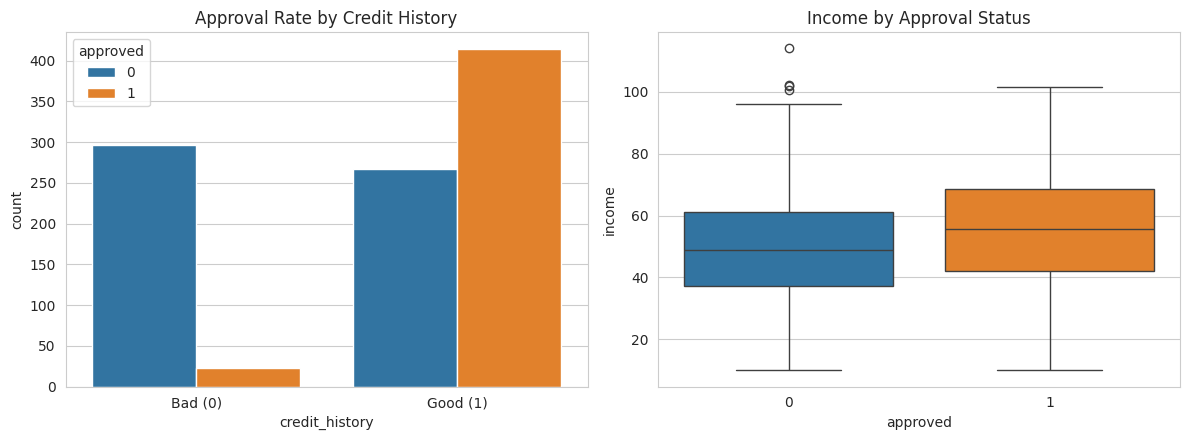

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(x="credit_history", hue="approved", data=df, ax=axes[0])
axes[0].set_title("Approval Rate by Credit History")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Bad (0)", "Good (1)"])

sns.boxplot(x="approved", y="income", hue="approved", data=df, ax=axes[1], legend=False)
axes[1].set_title("Income by Approval Status")

plt.tight_layout()
plt.show()


In [5]:
df.groupby("employment_type")["approved"].mean().sort_values(ascending=False).rename("approval_rate")


employment_type
Salaried         0.493761
Self-Employed    0.438746
Unemployed       0.068182
Name: approval_rate, dtype: float64

**Observations:**
- Credit history is the dominant factor: applicants with good credit history are approved far more often than
  those with bad credit history.
- Approved applicants tend to have somewhat higher income, but the overlap between the two groups is large - income
  alone is a weak signal.
- Employment type also matters: unemployed applicants have a much lower approval rate than salaried or
  self-employed applicants.


## 3. Preprocessing

`employment_type` is one-hot encoded. `credit_history` is already binary (0/1), so it is used as-is. No feature
scaling is applied - logistic regression's `lbfgs` solver converges fine here given the feature ranges, and it
keeps the coefficients directly interpretable. `stratify=y` is used in the split so the approve/reject ratio is
preserved in both train and test sets.


In [6]:
df_encoded = pd.get_dummies(df, columns=["employment_type"], drop_first=True, dtype=int)

X = df_encoded.drop(columns=["approved"])
y = df_encoded["approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.head()


,credit_history,income,loan_amount,employment_type_Self-Employed,employment_type_Unemployed
202,0,30.7,149.9,0,0
132,0,55.0,251.0,0,0
337,1,48.8,120.5,1,0
9,1,16.8,307.2,0,0
618,1,74.0,216.6,1,0


## 4. Model Training - Logistic Regression


In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model.coef_[0]
})


,feature,coefficient
0,credit_history,3.143936
1,income,0.020957
2,loan_amount,-0.008990
3,employment_type_Self-Employed,-0.273394
4,employment_type_Unemployed,-2.658215


Positive coefficients push the prediction towards approval, negative ones push towards rejection. `credit_history`
should carry the largest positive weight, and `employment_type_Unemployed` should be strongly negative - both
matching what was seen in the EDA.


## 5. Evaluation on Test Set


In [8]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy  : {acc:.3f}")
print(f"Precision : {prec:.3f}")
print(f"Recall    : {rec:.3f}")
print(f"F1-score  : {f1:.3f}")
print(f"ROC-AUC   : {auc:.3f}")


Accuracy  : 0.825
Precision : 0.777
Recall    : 0.839
F1-score  : 0.807
ROC-AUC   : 0.885


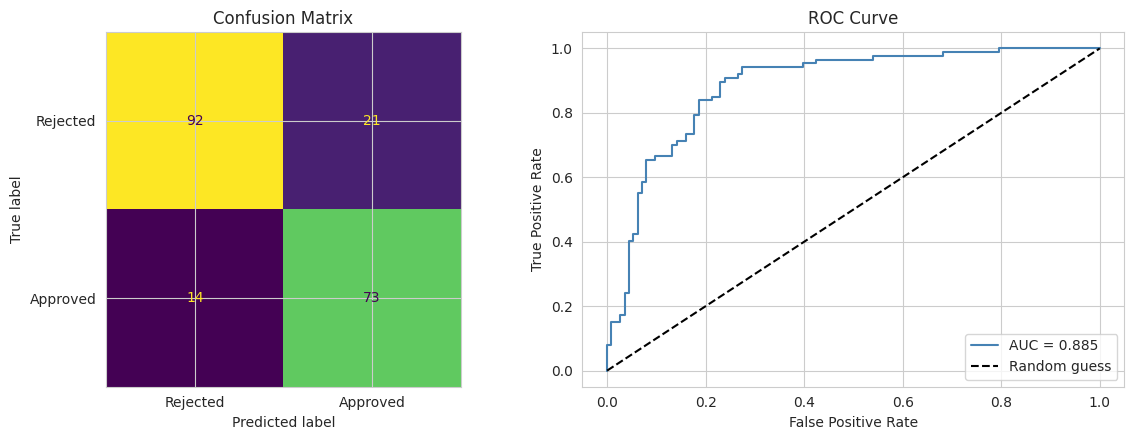

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Rejected", "Approved"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="steelblue")
axes[1].plot([0, 1], [0, 1], "k--", label="Random guess")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Conclusion

- Logistic Regression was trained to predict loan approval from `credit_history`, `income`, `loan_amount`, and
  `employment_type`.
- `credit_history` is by far the strongest predictor, followed by `employment_type` (unemployed applicants are
  penalized heavily); `income` and `loan_amount` have smaller, but expected-direction, effects.
- The ROC-AUC score indicates the model separates approved vs. rejected applicants well above chance level.
- **Possible extensions:** try class-weighting or SMOTE if the classes were more imbalanced, add an interaction
  term between income and loan amount (e.g. debt-to-income ratio), or compare against a tree-based classifier.
